In [1]:
import json
import random
from collections import defaultdict

with open("test_data_cleaned.jsonl", "r", encoding="utf-8") as f:
    all_data = [json.loads(line) for line in f]

lang_data = defaultdict(list)
for item in all_data:
    lang_data[item["lang"]].append(item)

for lang in lang_data:
    random.shuffle(lang_data[lang])

In [2]:
# Define target ratios (English %)
ratios = [0, 10, 20, 30, 40, 50, 60, 70, 80]

target_langs = [
    "bul_Cyrl",
    "kor_Hang",
    "jpn_Jpan",
    "spa_Latn"
]

for tgt in target_langs:
    print(f"\n English vs {tgt}")

    for eng_ratio in ratios:
        total_samples = 1000
        eng_count = int((eng_ratio/100)*total_samples)
        tgt_count = total_samples-eng_count

        new_data=[]
        new_data+=lang_data["eng_Latn"][:eng_count]
        new_data+=lang_data[tgt][:tgt_count]

        random.shuffle(new_data)

        filename=f"testset_eng_{tgt}_{eng_ratio}.jsonl"
        with open(filename,"w",encoding="utf-8") as f:
            for item in new_data:
                f.write(json.dumps(item,ensure_ascii=False)+"\n")

        print(f"{filename} saved.")


 English vs bul_Cyrl
testset_eng_bul_Cyrl_0.jsonl saved.
testset_eng_bul_Cyrl_10.jsonl saved.
testset_eng_bul_Cyrl_20.jsonl saved.
testset_eng_bul_Cyrl_30.jsonl saved.
testset_eng_bul_Cyrl_40.jsonl saved.
testset_eng_bul_Cyrl_50.jsonl saved.
testset_eng_bul_Cyrl_60.jsonl saved.
testset_eng_bul_Cyrl_70.jsonl saved.
testset_eng_bul_Cyrl_80.jsonl saved.

 English vs kor_Hang
testset_eng_kor_Hang_0.jsonl saved.
testset_eng_kor_Hang_10.jsonl saved.
testset_eng_kor_Hang_20.jsonl saved.
testset_eng_kor_Hang_30.jsonl saved.
testset_eng_kor_Hang_40.jsonl saved.
testset_eng_kor_Hang_50.jsonl saved.
testset_eng_kor_Hang_60.jsonl saved.
testset_eng_kor_Hang_70.jsonl saved.
testset_eng_kor_Hang_80.jsonl saved.

 English vs jpn_Jpan
testset_eng_jpn_Jpan_0.jsonl saved.
testset_eng_jpn_Jpan_10.jsonl saved.
testset_eng_jpn_Jpan_20.jsonl saved.
testset_eng_jpn_Jpan_30.jsonl saved.
testset_eng_jpn_Jpan_40.jsonl saved.
testset_eng_jpn_Jpan_50.jsonl saved.
testset_eng_jpn_Jpan_60.jsonl saved.
testset_eng_

In [3]:
import os
import torch
import pandas as pd
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

model_id = "allenai/OLMoE-1B-7B-0924"
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4"
)
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=quant_config,
    device_map="auto"
)
model.eval()

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

OlmoeForCausalLM(
  (model): OlmoeModel(
    (embed_tokens): Embedding(50304, 2048, padding_idx=1)
    (layers): ModuleList(
      (0-15): 16 x OlmoeDecoderLayer(
        (self_attn): OlmoeSdpaAttention(
          (q_proj): Linear4bit(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear4bit(in_features=2048, out_features=2048, bias=False)
          (v_proj): Linear4bit(in_features=2048, out_features=2048, bias=False)
          (o_proj): Linear4bit(in_features=2048, out_features=2048, bias=False)
          (q_norm): OlmoeRMSNorm((2048,), eps=1e-05)
          (k_norm): OlmoeRMSNorm((2048,), eps=1e-05)
        )
        (mlp): OlmoeSparseMoeBlock(
          (gate): Linear4bit(in_features=2048, out_features=64, bias=False)
          (experts): ModuleList(
            (0-63): 64 x OlmoeMLP(
              (gate_proj): Linear4bit(in_features=2048, out_features=1024, bias=False)
              (up_proj): Linear4bit(in_features=2048, out_features=1024, bias=False)
        

In [4]:
router_logs={}

def get_router_hook(layer_name):
    def hook(module,inputs,outputs):
        val=outputs[1] if isinstance(outputs,tuple) else outputs
        if isinstance(val,torch.Tensor) and val.shape[-1]==64:
            router_logs[layer_name]=val.detach().float().cpu()
    return hook

target_layer="model.layers.14.mlp.gate"

for name,module in model.named_modules():
    if name==target_layer:
        module.register_forward_hook(get_router_hook(name))

for tgt in target_langs:
    for ratio in ratios:

        file_path=f"testset_eng_{tgt}_{ratio}.jsonl"
        print(f"\nRunning: {file_path}")

        with open(file_path,"r",encoding="utf-8") as f:
            test_data=[json.loads(line) for line in f]

        router_data=[]

        for i,item in enumerate(tqdm(test_data)):
            lang=item["lang"]
            text=item["text"]

            inputs=tokenizer(text,return_tensors="pt").to(model.device)
            router_logs.clear()

            with torch.no_grad():
                _=model(**inputs)

            if target_layer in router_logs:
                logits=router_logs[target_layer]
                expert_ids=logits.argmax(dim=-1).tolist()

                for idx,expert in enumerate(expert_ids):
                    router_data.append({
                        "lang":lang,
                        "sentence_id":i,
                        "token_idx":idx,
                        "expert_id":expert
                    })

        df=pd.DataFrame(router_data)
        df.to_csv(f"router_logs_eng_{tgt}_{ratio}.csv",index=False)

        print("Saved.")


Running: testset_eng_bul_Cyrl_0.jsonl


100%|███████████████████████████████████████████████████████████████████████████████| 1000/1000 [14:30<00:00,  1.15it/s]


Saved.

Running: testset_eng_bul_Cyrl_10.jsonl


100%|███████████████████████████████████████████████████████████████████████████████| 1000/1000 [14:16<00:00,  1.17it/s]


Saved.

Running: testset_eng_bul_Cyrl_20.jsonl


...

Saved.

Running: testset_eng_spa_Latn_70.jsonl


100%|███████████████████████████████████████████████████████████████████████████████| 1000/1000 [13:29<00:00,  1.24it/s]


Saved.

Running: testset_eng_spa_Latn_80.jsonl


100%|███████████████████████████████████████████████████████████████████████████████| 1000/1000 [13:28<00:00,  1.24it/s]

Saved.


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def compute_entropy(counts):
    probs = counts / counts.sum()
    return -np.sum(probs * np.log2(probs + 1e-9))

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.entropy.html

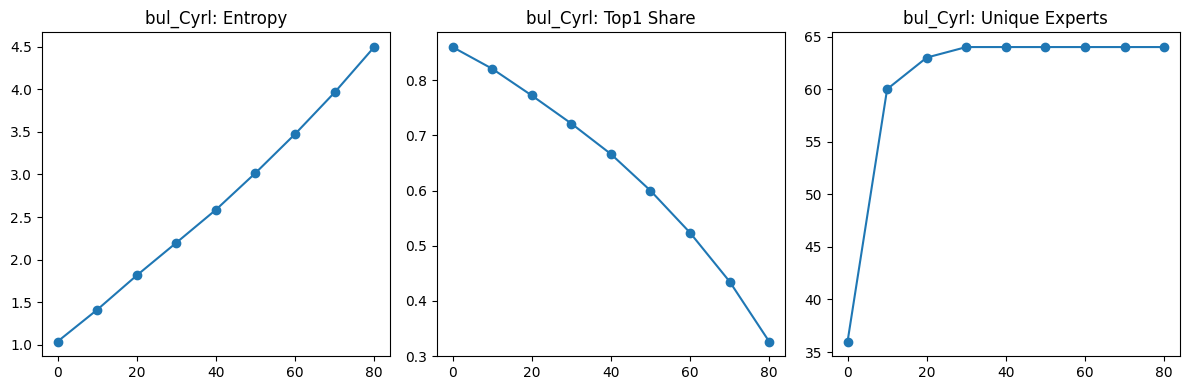

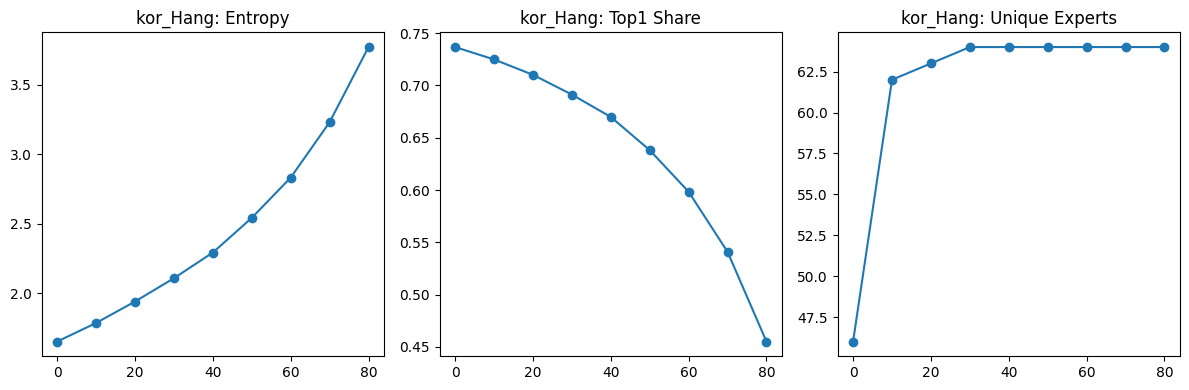

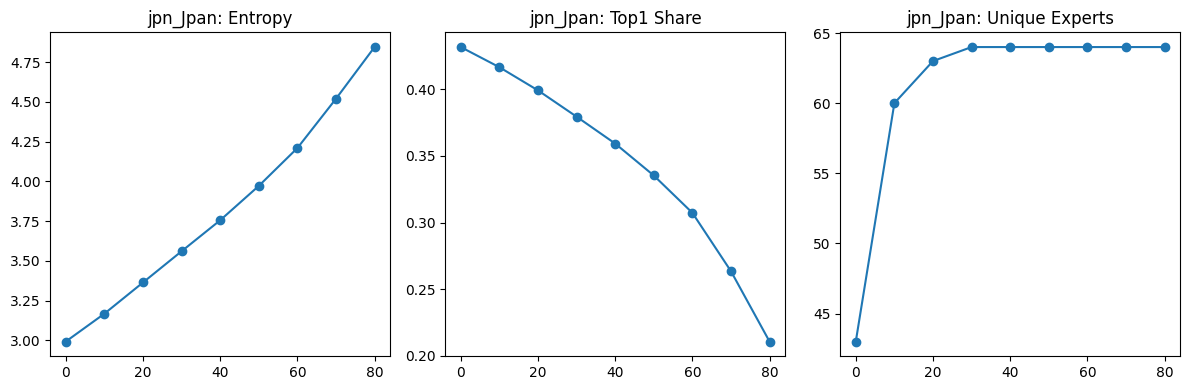

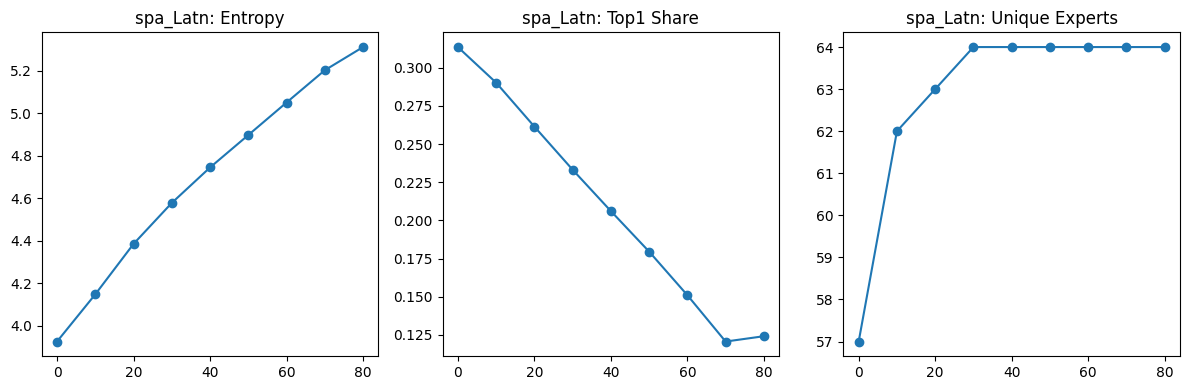

In [6]:
for tgt in target_langs:

    entropies=[]
    top1=[]
    unique=[]

    for r in ratios:
        df=pd.read_csv(f"router_logs_eng_{tgt}_{r}.csv")

        counts=df["expert_id"].value_counts()

        entropies.append(compute_entropy(counts.values))
        top1.append(counts.iloc[0]/counts.sum())
        unique.append(len(counts))

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.plot(ratios,entropies,marker='o')
    plt.title(f"{tgt}: Entropy")

    plt.subplot(1,3,2)
    plt.plot(ratios,top1,marker='o')
    plt.title(f"{tgt}: Top1 Share")

    plt.subplot(1,3,3)
    plt.plot(ratios,unique,marker='o')
    plt.title(f"{tgt}: Unique Experts")

    plt.tight_layout()
    plt.show()